In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

ds = load_dataset("howardzhao3/train24", "default", split="train")

print(ds)
print(ds[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


final_integrated_data.csv:   0%|          | 0.00/761M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2419098 [00:00<?, ? examples/s]

Dataset({
    features: ['site_id', 'direction', 'year', 'month', 'day', 'hour', 'lat_x', 'lon', 'count', 'obs_count', 'time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration', 'site_nr', 'long', 'lat_y', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count', 'description'],
    num_rows: 2419098
})
{'site_id': 1, 'direction': 'in', 'year': 2024, 'month': 1, 'day': 1, 'hour': 0, 'lat_x': 50.916183, 'lon': 4.456122, 'count': 0.0, 'obs_count': 4, 'time': '2024-01-01 00:00:00', 'temperature_2m': 7.85, 'apparent_temperature': 0.9682741, 'relative_humidity_2m': 72.43961, 'precipitation': 0.0, 'rain': 0.0, 'snowfall': 0.0, 'wind_speed_10m': 10.104455, 'shortwave_radiation': 0.0, 'direct_normal_irradiance': 0.0, 'sunshine_duration': 0.0, '

In [2]:
df = ds.to_pandas()
print(df.shape)
print(df.columns.tolist())
df.head()

(2419098, 37)
['site_id', 'direction', 'year', 'month', 'day', 'hour', 'lat_x', 'lon', 'count', 'obs_count', 'time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration', 'site_nr', 'long', 'lat_y', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count', 'description']


,site_id,direction,year,month,day,hour,lat_x,lon,count,obs_count,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo


In [3]:
df_2024 = df.copy()
if "year" in df_2024.columns:
    df_2024 = df_2024[df_2024["year"] == 2024].copy()

# Create date column if year/month/day columns exist
if all(col in df_2024.columns for col in ["year", "month", "day"]):
    df_2024["date_dt"] = pd.to_datetime(
        df_2024[["year", "month", "day"]],
        errors="coerce"
    )
else:
    print("No year/month/day columns found. Check your date column manually.")

# Create day-of-week and weekend flag
df_2024["day_of_week"] = df_2024["date_dt"].dt.dayofweek
df_2024["is_weekend_binary"] = df_2024["day_of_week"].isin([5, 6]).astype(int)

# Rush hour flag
if "hour" in df_2024.columns:
    df_2024["is_rush_hour"] = df_2024["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
else:
    print("No hour column found. Rush-hour features will not be correct.")
    df_2024["is_rush_hour"] = 0

# Make sure count is numeric
df_2024["count"] = pd.to_numeric(df_2024["count"], errors="coerce")


In [4]:
print(df_2024.shape)
df_2024.head()

(2419098, 41)


,site_id,direction,year,month,day,hour,lat_x,lon,count,obs_count,...,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description,date_dt,day_of_week,is_weekend_binary,is_rush_hour
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0


In [5]:
cluster_unit = "site_id"

if cluster_unit not in df_2024.columns:
    print("site_id column not found. Available columns are:")
    print(df_2024.columns.tolist())

In [6]:
df_2024["weekday_count"] = np.where(
    df_2024["is_weekend_binary"] == 0,
    df_2024["count"],
    np.nan
)

df_2024["weekend_count"] = np.where(
    df_2024["is_weekend_binary"] == 1,
    df_2024["count"],
    np.nan
)

df_2024["rush_hour_count"] = np.where(
    df_2024["is_rush_hour"] == 1,
    df_2024["count"],
    np.nan
)

In [7]:
#aggregate data by sites
agg_dict = {
    # cycling volume
    "mean_count": ("count", "mean"),
    "median_count": ("count", "median"),
    "max_count": ("count", "max"),
    "std_count": ("count", "std"),

    # temporal behaviour
    "weekday_mean": ("weekday_count", "mean"),
    "weekend_mean": ("weekend_count", "mean"),
    "rush_hour_mean": ("rush_hour_count", "mean"),
}

# Add weather columns only if they exist
optional_features = {
    "mean_temperature": "temperature_2m",
    "mean_precipitation": "precipitation",
    "mean_wind": "wind_speed_10m",
    "mean_solar": "shortwave_radiation",
    "mean_humidity": "relative_humidity_2m",

    # spatial infrastructure
    "park_count": "park_count",
    "school_count": "school_count",
    "station_count": "station_count",
    "dist_nearest_station": "dist_nearest_station",
    "dist_nearest_school": "dist_nearest_school",

    # mapping columns
    "lat": "lat_x",
    "lon": "lon",
}

for new_name, old_col in optional_features.items():
    if old_col in df_2024.columns:
        agg_dict[new_name] = (old_col, "mean")

# Add municipality/gemeente label if available
if "gemeente" in df_2024.columns:
    agg_dict["gemeente"] = ("gemeente", "first")

site_cluster_df = df_2024.groupby(cluster_unit).agg(**agg_dict).reset_index()

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,mean_solar,mean_humidity,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,124.834130,80.685045,0.0,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,123.896403,80.977477,0.0,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,123.896403,80.977477,0.0,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,123.720515,80.552367,0.0,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,123.720515,80.552367,0.0,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen


In [8]:
site_cluster_df["weekend_weekday_ratio"] = (
    site_cluster_df["weekend_mean"] / (site_cluster_df["weekday_mean"] + 1e-6)
)

site_cluster_df["rush_regular_ratio"] = (
    site_cluster_df["rush_hour_mean"] / (site_cluster_df["mean_count"] + 1e-6)
)

site_cluster_df["count_variability"] = (
    site_cluster_df["std_count"] / (site_cluster_df["mean_count"] + 1e-6)
)

site_cluster_df = site_cluster_df.replace([np.inf, -np.inf], np.nan)

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971


In [9]:
# Remove inactive / zero-count sites before clustering
active_sites_df = site_cluster_df[
    (site_cluster_df["mean_count"] > 0) &
    (site_cluster_df["max_count"] > 0)
].copy()

print("Before filtering:", site_cluster_df.shape)
print("After filtering:", active_sites_df.shape)

active_sites_df.head()

Before filtering: (140, 24)
After filtering: (136, 24)


,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971


In [10]:
clustering_features_clean = [
    "mean_count",
    "median_count",
    "max_count",
    "std_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean",
    "weekend_weekday_ratio",
    "rush_regular_ratio",
    "count_variability",
    "park_count",
    "school_count",
    "station_count",
    "dist_nearest_station",
    "dist_nearest_school"
]

clustering_features_clean = [
    col for col in clustering_features_clean
    if col in active_sites_df.columns
]

print("Final clustering features:")
print(clustering_features_clean)

Final clustering features:
['mean_count', 'median_count', 'max_count', 'std_count', 'weekday_mean', 'weekend_mean', 'rush_hour_mean', 'weekend_weekday_ratio', 'rush_regular_ratio', 'count_variability', 'park_count', 'school_count', 'station_count', 'dist_nearest_station', 'dist_nearest_school']


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

X_active = active_sites_df[clustering_features_clean].copy()
X_active = X_active.replace([np.inf, -np.inf], np.nan)

count_like_features = [
    "mean_count",
    "median_count",
    "max_count",
    "std_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean"
]

X_active_transformed = X_active.copy()

for col in count_like_features:
    if col in X_active_transformed.columns:
        X_active_transformed[col] = np.log1p(X_active_transformed[col])

imputer = SimpleImputer(strategy="median")
X_active_imputed = imputer.fit_transform(X_active_transformed)

scaler = StandardScaler()
X_active_scaled = scaler.fit_transform(X_active_imputed)

print(X_active_scaled.shape)

(136, 15)


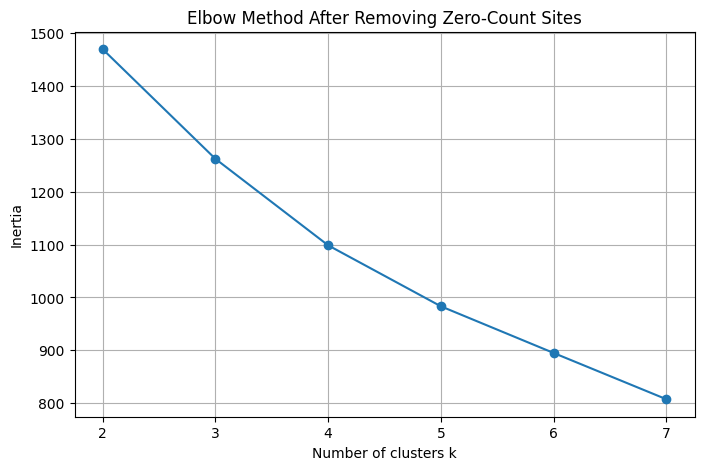

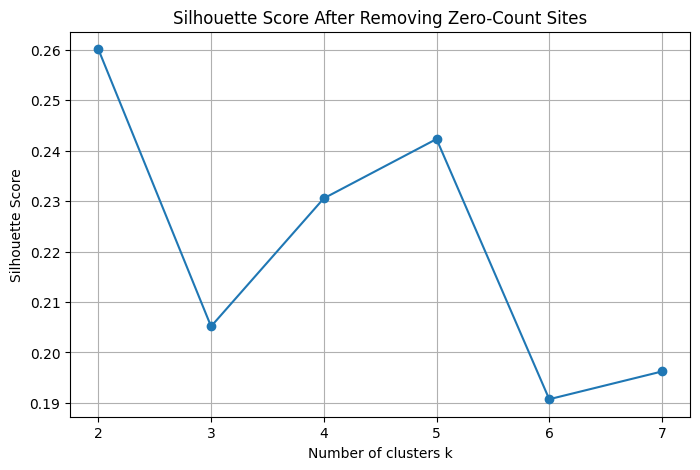

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_active_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_active_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method After Removing Zero-Count Sites")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score After Removing Zero-Count Sites")
plt.grid(True)
plt.show()

In [13]:
best_k = 2

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

active_sites_df["cluster"] = final_kmeans.fit_predict(X_active_scaled)

active_sites_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability,cluster
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892,0
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661,1
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981,1
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,0.0,2936.036400,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634,0
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,0.0,2929.505988,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971,0


In [14]:
active_sites_df["cluster"].value_counts().sort_index()

,count
cluster,
0,82
1,54


In [15]:
cluster_summary = (
    active_sites_df
    .groupby("cluster")[clustering_features_clean]
    .mean()
    .round(2)
)

cluster_summary

,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,weekend_weekday_ratio,rush_regular_ratio,count_variability,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school
cluster,,,,,,,,,,,,,,,
0,4.93,1.13,182.45,9.52,5.43,3.66,8.52,0.71,1.73,2.14,0.62,0.62,0.0,2383.85,1102.23
1,19.66,9.44,569.69,29.97,21.38,15.32,34.67,0.74,1.77,1.68,2.89,3.11,0.2,1421.20,690.94


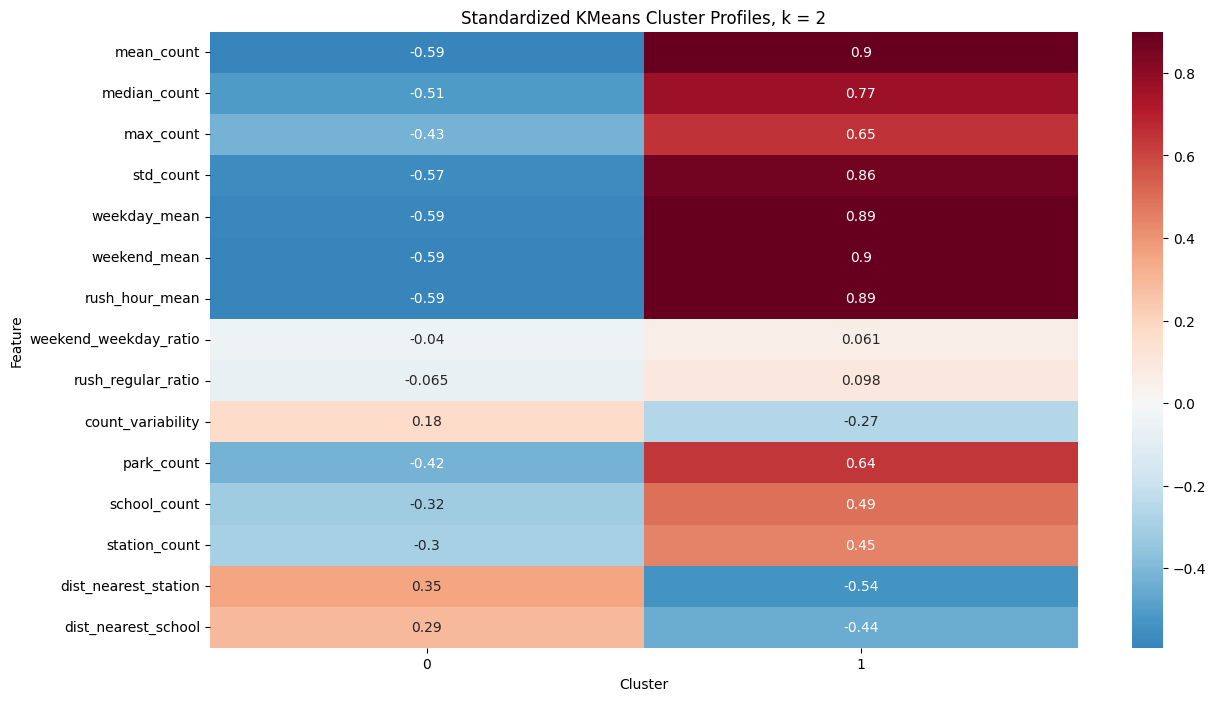

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df = pd.DataFrame(
    X_active_scaled,
    columns=clustering_features_clean
)

scaled_df["cluster"] = active_sites_df["cluster"].values

scaled_cluster_summary = scaled_df.groupby("cluster").mean()

plt.figure(figsize=(14, 8))
sns.heatmap(
    scaled_cluster_summary.T,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Standardized KMeans Cluster Profiles, k = 2")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.show()

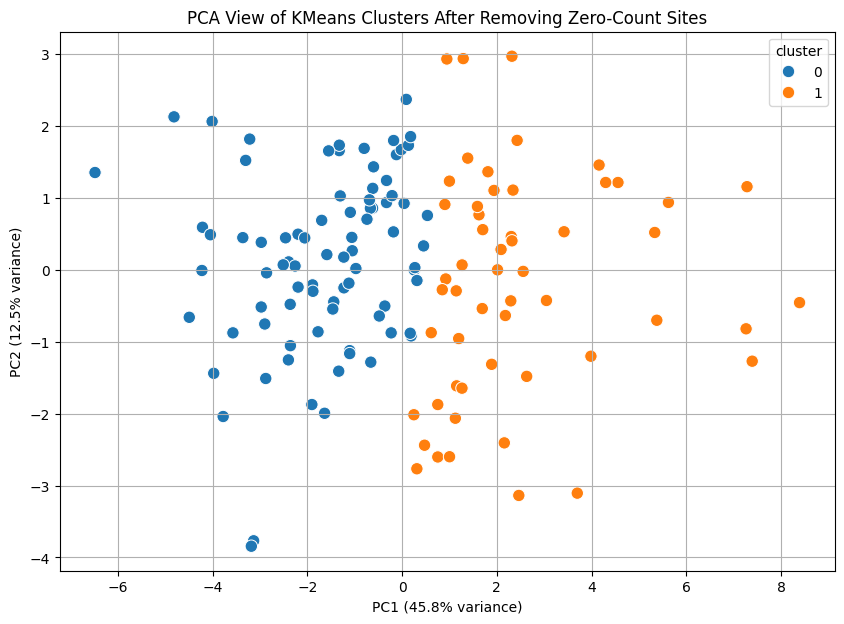

In [17]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_active_scaled)

active_sites_df["PC1"] = pca_result[:, 0]
active_sites_df["PC2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=active_sites_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=80
)

plt.title("PCA View of KMeans Clusters After Removing Zero-Count Sites")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.grid(True)
plt.show()

In [18]:
import plotly.express as px

if "lat" in active_sites_df.columns and "lon" in active_sites_df.columns:

    hover_cols = [
        col for col in [
            cluster_unit,
            "gemeente",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "park_count",
            "school_count",
            "station_count"
        ]
        if col in active_sites_df.columns
    ]

    fig = px.scatter_mapbox(
        active_sites_df,
        lat="lat",
        lon="lon",
        color=active_sites_df["cluster"].astype(str),
        size="mean_count",
        hover_data=hover_cols,
        zoom=7,
        mapbox_style="carto-positron",
        title="Spatial Distribution of 2024 Cycling Site Clusters"
    )

    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    fig.show()

else:
    print("Latitude/longitude columns not available for mapping.")

In [19]:
cluster_labels = {
    0: "Lower-activity / peripheral sites",
    1: "Higher-activity / infrastructure-supported sites"
}

active_sites_df["cluster_label"] = active_sites_df["cluster"].map(cluster_labels)

active_sites_df[["site_id", "cluster", "cluster_label", "mean_count", "park_count", "school_count", "station_count"]].head()

,site_id,cluster,cluster_label,mean_count,park_count,school_count,station_count
0,1,0,Lower-activity / peripheral sites,8.394581,0.0,0.0,0.0
1,2,1,Higher-activity / infrastructure-supported sites,16.595856,0.0,0.0,0.0
2,3,1,Higher-activity / infrastructure-supported sites,15.415813,0.0,0.0,0.0
3,4,0,Lower-activity / peripheral sites,3.782445,0.0,1.0,0.0
4,5,0,Lower-activity / peripheral sites,3.940574,0.0,1.0,0.0


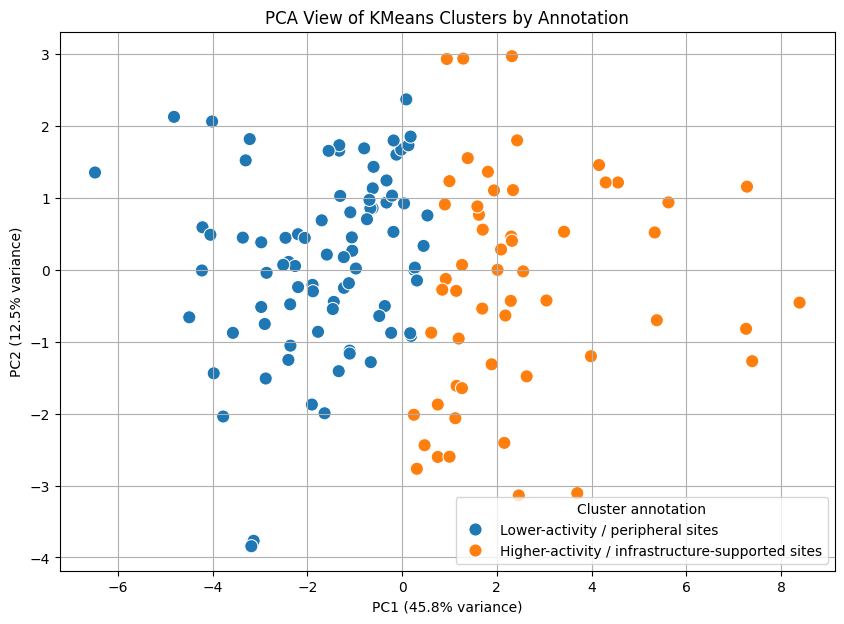

In [20]:


pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_active_scaled)

active_sites_df["PC1"] = pca_result[:, 0]
active_sites_df["PC2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=active_sites_df,
    x="PC1",
    y="PC2",
    hue="cluster_label",
    s=90
)

plt.title("PCA View of KMeans Clusters by Annotation")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster annotation")
plt.grid(True)
plt.show()

In [21]:
cluster_info = active_sites_df[
    ["site_id", "cluster", "cluster_label"]
].copy()

df_clustered = df_2024.merge(
    cluster_info,
    on="site_id",
    how="inner"
)

df_clustered.shape

(2368048, 46)

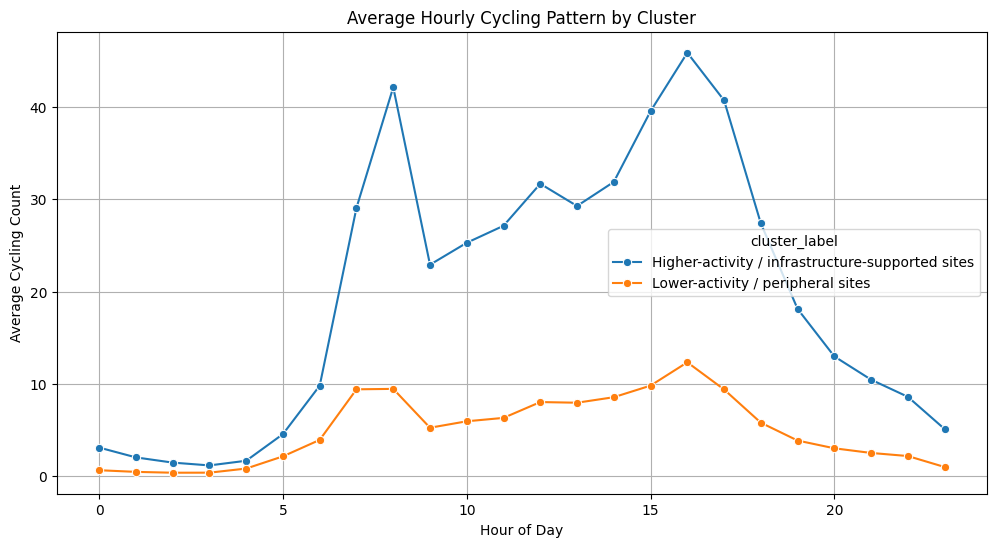

In [22]:
hourly_profile = (
    df_clustered
    .groupby(["cluster_label", "hour"])["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_profile,
    x="hour",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Average Hourly Cycling Pattern by Cluster")
plt.xlabel("Hour of Day")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

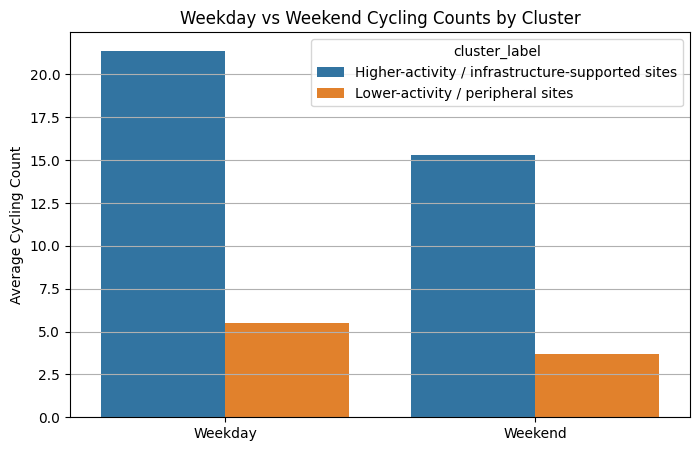

In [23]:
weekday_profile = (
    df_clustered
    .groupby(["cluster_label", "is_weekend_binary"])["count"]
    .mean()
    .reset_index()
)

weekday_profile["day_type"] = weekday_profile["is_weekend_binary"].map({
    0: "Weekday",
    1: "Weekend"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weekday_profile,
    x="day_type",
    y="count",
    hue="cluster_label"
)

plt.title("Weekday vs Weekend Cycling Counts by Cluster")
plt.xlabel("")
plt.ylabel("Average Cycling Count")
plt.grid(axis="y")
plt.show()

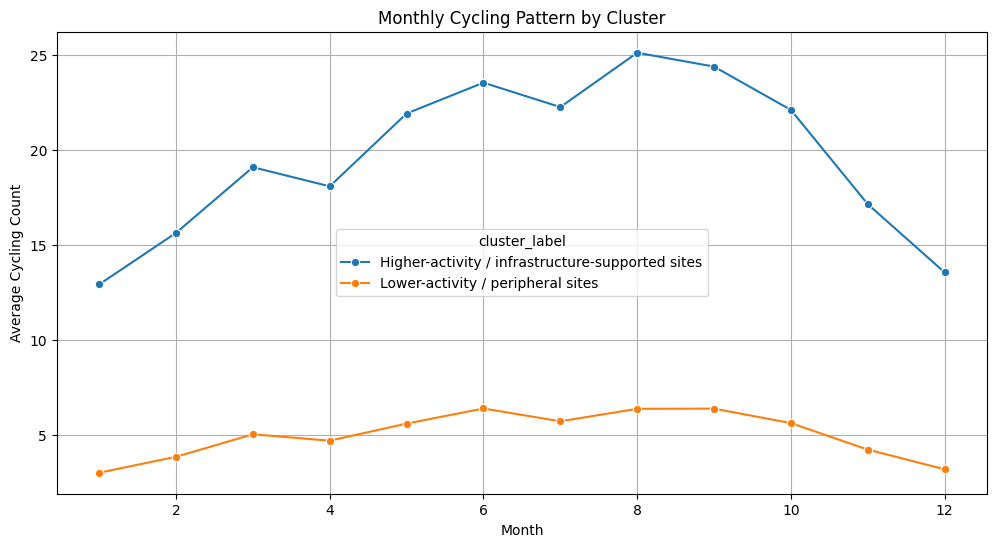

In [24]:
monthly_profile = (
    df_clustered
    .groupby(["cluster_label", "month"])["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_profile,
    x="month",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Monthly Cycling Pattern by Cluster")
plt.xlabel("Month")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

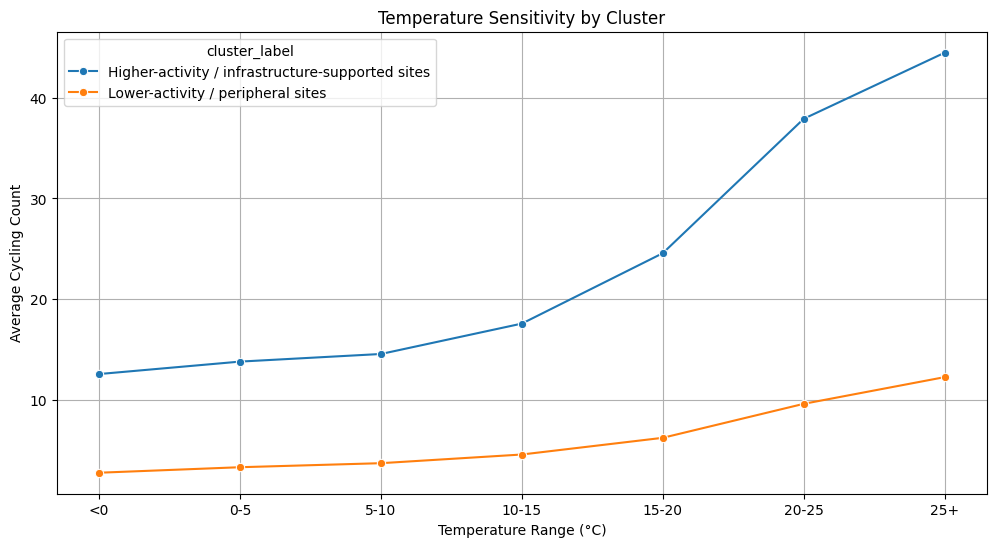

In [25]:
df_clustered["temperature_bin"] = pd.cut(
    df_clustered["temperature_2m"],
    bins=[-10, 0, 5, 10, 15, 20, 25, 35],
    labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", "25+"]
)

temp_profile = (
    df_clustered
    .groupby(["cluster_label", "temperature_bin"], observed=True)["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=temp_profile,
    x="temperature_bin",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Temperature Sensitivity by Cluster")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

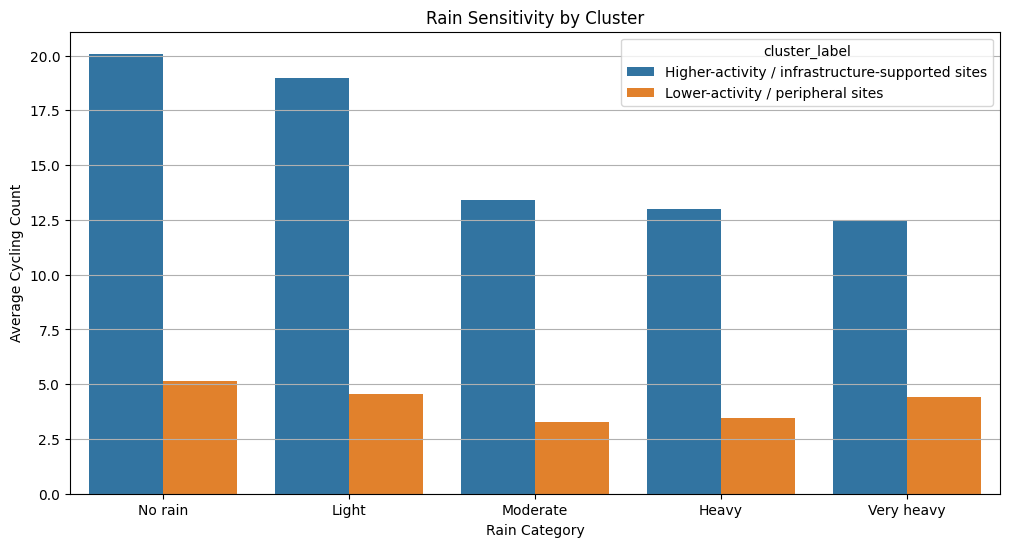

In [26]:
df_clustered["rain_category"] = pd.cut(
    df_clustered["precipitation"],
    bins=[-0.01, 0, 1, 3, 10, 100],
    labels=["No rain", "Light", "Moderate", "Heavy", "Very heavy"]
)

rain_profile = (
    df_clustered
    .groupby(["cluster_label", "rain_category"], observed=True)["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=rain_profile,
    x="rain_category",
    y="count",
    hue="cluster_label"
)

plt.title("Rain Sensitivity by Cluster")
plt.xlabel("Rain Category")
plt.ylabel("Average Cycling Count")
plt.grid(axis="y")
plt.show()

In [27]:
representative_sites = (
    active_sites_df
    .sort_values(["cluster", "mean_count"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
)

representative_sites[
    ["site_id", "cluster_label", "mean_count", "weekday_mean", "weekend_mean",
     "rush_hour_mean", "park_count", "school_count", "station_count"]
]

,site_id,cluster_label,mean_count,weekday_mean,weekend_mean,rush_hour_mean,park_count,school_count,station_count
111,112,Lower-activity / peripheral sites,10.809995,13.083492,5.082532,14.800319,0.0,0.0,0.0
126,127,Lower-activity / peripheral sites,10.179133,12.434001,4.498598,14.717213,0.0,0.0,0.0
83,84,Lower-activity / peripheral sites,10.175603,11.485926,6.874599,19.875911,0.0,0.0,0.0
60,61,Lower-activity / peripheral sites,9.861965,11.200620,6.489583,21.951047,0.0,0.0,0.0
61,62,Lower-activity / peripheral sites,9.781364,11.131282,6.380609,18.612250,0.0,0.0,0.0
139,143,Higher-activity / infrastructure-supported sites,90.070014,99.965013,65.142228,160.357696,12.0,4.0,0.0
106,107,Higher-activity / infrastructure-supported sites,86.822291,95.233540,65.632412,159.028233,0.0,7.0,0.0
68,69,Higher-activity / infrastructure-supported sites,47.373008,54.816396,28.621394,90.230191,6.0,25.0,0.0
63,64,Higher-activity / infrastructure-supported sites,43.915699,40.938534,51.415865,60.178962,3.0,3.0,0.0
135,137,Higher-activity / infrastructure-supported sites,42.263604,46.215410,32.308093,72.055783,1.0,8.0,0.0


In [28]:
infra_summary = (
    active_sites_df
    .groupby("cluster_label")[
        ["park_count", "school_count", "station_count",
         "dist_nearest_station", "dist_nearest_school"]
    ]
    .mean()
    .round(2)
)

infra_summary

,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school
cluster_label,,,,,
Higher-activity / infrastructure-supported sites,2.89,3.11,0.2,1421.20,690.94
Lower-activity / peripheral sites,0.62,0.62,0.0,2383.85,1102.23


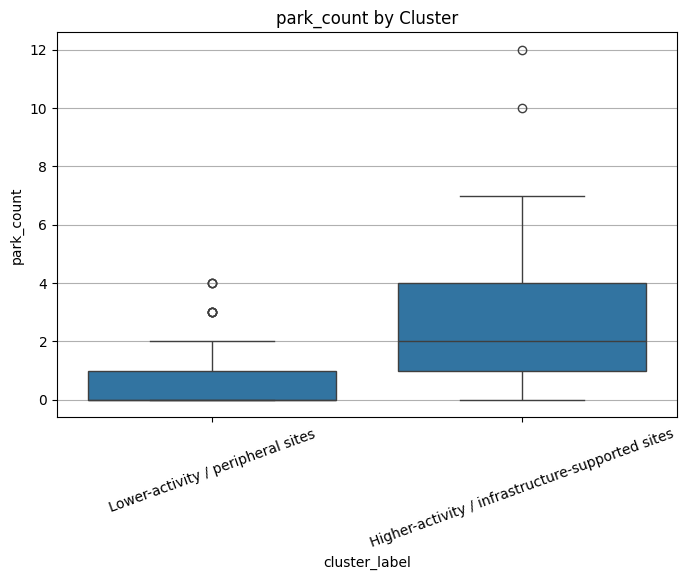

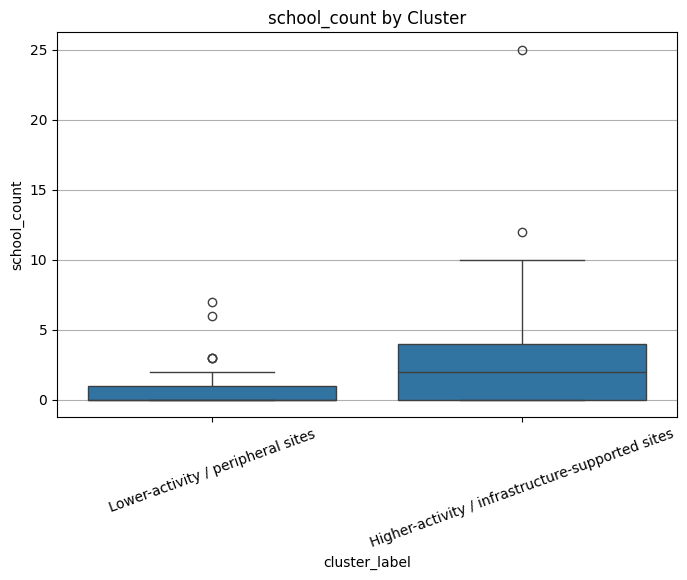

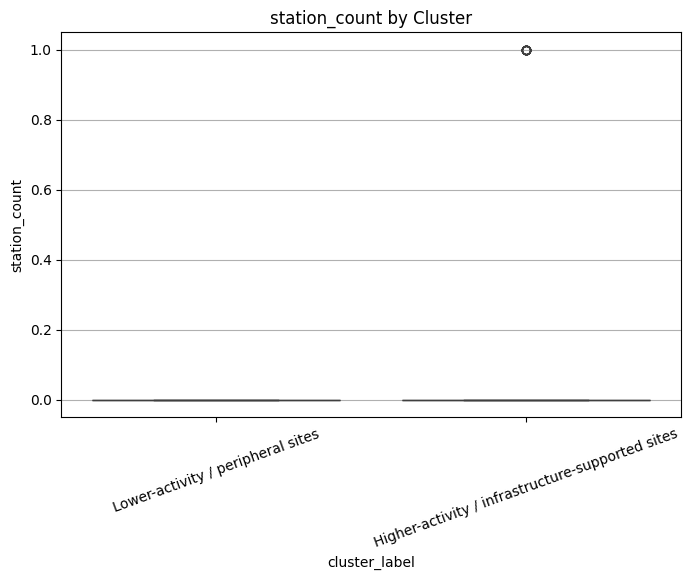

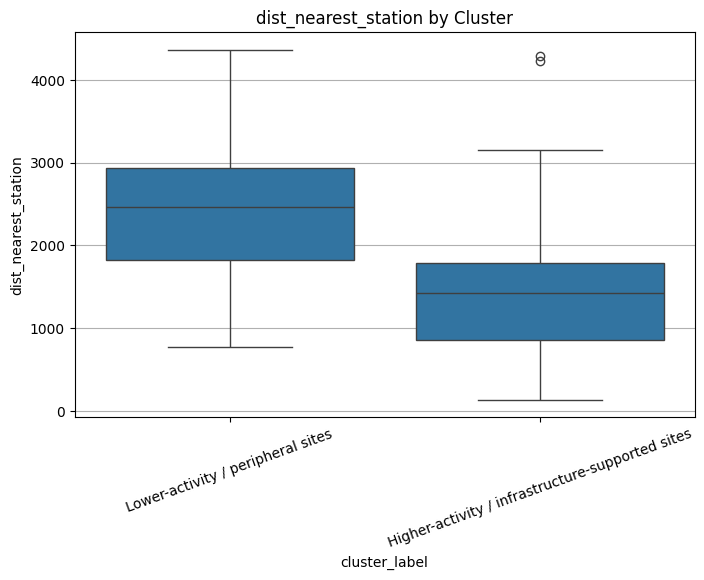

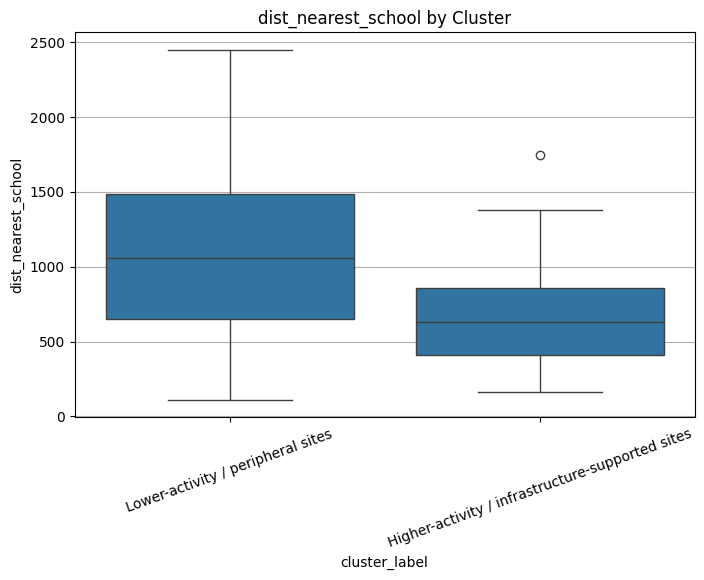

In [29]:
infra_features = [
    "park_count",
    "school_count",
    "station_count",
    "dist_nearest_station",
    "dist_nearest_school"
]

for feature in infra_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=active_sites_df,
        x="cluster_label",
        y=feature
    )
    plt.title(f"{feature} by Cluster")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.show()

In [30]:
# Save final 2024 KMeans model clearly
kmeans_2024 = final_kmeans

# Save final 2024 clustered site dataframe clearly
active_sites_2024 = active_sites_df.copy()

active_sites_2024["cluster_2024"] = active_sites_2024["cluster"]
active_sites_2024["cluster_label_2024"] = active_sites_2024["cluster_label"]

active_sites_2024[[
    "site_id",
    "cluster_2024",
    "cluster_label_2024",
    "mean_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean"
]].head()

,site_id,cluster_2024,cluster_label_2024,mean_count,weekday_mean,weekend_mean,rush_hour_mean
0,1,0,Lower-activity / peripheral sites,8.394581,9.287691,6.144631,15.245902
1,2,1,Higher-activity / infrastructure-supported sites,16.595856,19.301924,9.778646,31.885018
2,3,1,Higher-activity / infrastructure-supported sites,15.415813,17.824268,9.348357,30.094490
3,4,0,Lower-activity / peripheral sites,3.782445,3.932252,3.405048,6.005464
4,5,0,Lower-activity / peripheral sites,3.940574,4.074109,3.604167,6.266166


In [31]:
print("2024 model clusters:", kmeans_2024.n_clusters)

active_sites_2024["cluster_label_2024"].value_counts()

2024 model clusters: 2


,count
cluster_label_2024,
Lower-activity / peripheral sites,82
Higher-activity / infrastructure-supported sites,54


In [32]:
required_objects = [
    "active_sites_2024",
    "kmeans_2024",
    "imputer",
    "scaler",
    "clustering_features_clean",
    "count_like_features"
]

for obj in required_objects:
    print(obj, "exists" if obj in globals() else "MISSING")

active_sites_2024 exists
kmeans_2024 exists
imputer exists
scaler exists
clustering_features_clean exists
count_like_features exists


In [36]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [37]:
import pandas as pd
import numpy as np
import os

parquet_path = "/content/drive/MyDrive/Colab Notebooks/fietstellingen_clean.parquet"

print(os.path.exists(parquet_path))

True


In [38]:
# Columns needed for 2025 clustering
needed_cols = [
    "site_id",
    "start_time",
    "end_time",
    "count",
    "lat",
    "lon",
    "site_name",
    "municipality",
    "year",
    "month",
    "day",
    "hour",
    "minute",
    "day_of_week",
    "is_weekend"
]

# First read only useful columns
df_all_small = pd.read_parquet(
    parquet_path,
    columns=needed_cols
)

print(df_all_small.shape)
df_all_small.head()

(30830936, 15)


,site_id,start_time,end_time,count,lat,lon,site_name,municipality,year,month,day,hour,minute,day_of_week,is_weekend
0,1,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,50.916183,4.456122,Machelen,Machelen,2023,1,1,0,0,6,True
1,1,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,50.916183,4.456122,Machelen,Machelen,2023,1,1,0,15,6,True
2,1,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,50.916183,4.456122,Machelen,Machelen,2023,1,1,0,30,6,True
3,1,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,50.916183,4.456122,Machelen,Machelen,2023,1,1,0,45,6,True
4,1,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,50.916183,4.456122,Machelen,Machelen,2023,1,1,1,0,6,True


In [40]:
df_2025 = df_all_small[df_all_small["year"].astype(int) == 2025].copy()

print("2025 shape:", df_2025.shape)
df_2025.head()

2025 shape: (9908890, 15)


,site_id,start_time,end_time,count,lat,lon,site_name,municipality,year,month,day,hour,minute,day_of_week,is_weekend
70172,1,2025-01-01 00:00:00,2025-01-01 00:15:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,1,0,0,2,False
70173,1,2025-01-01 00:15:00,2025-01-01 00:30:00,1.0,50.916183,4.456122,Machelen,Machelen,2025,1,1,0,15,2,False
70174,1,2025-01-01 00:30:00,2025-01-01 00:45:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,1,0,30,2,False
70175,1,2025-01-01 00:45:00,2025-01-01 01:00:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,1,0,45,2,False
70176,1,2025-01-01 01:00:00,2025-01-01 01:15:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,1,1,0,2,False


In [41]:


enriched_path = "/content/drive/MyDrive/Colab Notebooks/enriched_sites.csv"

enriched_sites = pd.read_csv(enriched_path)

print(enriched_sites.shape)
print(enriched_sites.columns.tolist())
enriched_sites.head()

(150, 16)
['site_ID', 'site_nr', 'long', 'lat', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count']


,site_ID,site_nr,long,lat,naam,domein,wegnr,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,4223.596605,1004.367360,0,0,0
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22,4283.438956,1041.580638,0,0,0
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,2936.036400,788.693562,1,0,0
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,2929.505988,785.493710,1,0,0
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22,216.792818,420.736564,4,1,3


In [42]:
enriched_sites_clean = enriched_sites.rename(columns={
    "site_ID": "site_id",
    "long": "site_lon_enriched",
    "lat": "site_lat_enriched",
    "gemeente": "municipality_enriched",
    "naam": "site_name_enriched"
})

df_2025["site_id"] = pd.to_numeric(df_2025["site_id"], errors="coerce")
enriched_sites_clean["site_id"] = pd.to_numeric(
    enriched_sites_clean["site_id"],
    errors="coerce"
)

enriched_keep_cols = [
    "site_id",
    "site_lon_enriched",
    "site_lat_enriched",
    "municipality_enriched",
    "site_name_enriched",
    "dist_nearest_station",
    "dist_nearest_school",
    "school_count",
    "station_count",
    "park_count"
]

enriched_sites_clean = enriched_sites_clean[
    [col for col in enriched_keep_cols if col in enriched_sites_clean.columns]
].drop_duplicates(subset=["site_id"])

enriched_sites_clean.head()

,site_id,site_lon_enriched,site_lat_enriched,municipality_enriched,site_name_enriched,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count
0,2,4.47169,51.27512,Brasschaat,Brasschaat 2,4223.596605,1004.367360,0,0,0
1,3,4.47222,51.27503,Brasschaat,Brasschaat 1,4283.438956,1041.580638,0,0,0
2,4,5.19011,51.16023,Balen,Balen 1,2936.036400,788.693562,1,0,0
3,5,5.19003,51.16018,Balen,Balen 2,2929.505988,785.493710,1,0,0
4,6,3.70298,51.10894,Evergem,Evergem 2,216.792818,420.736564,4,1,3


In [43]:
cycling_sites_2025 = set(df_2025["site_id"].dropna().unique())
enriched_site_ids = set(enriched_sites_clean["site_id"].dropna().unique())

overlap = cycling_sites_2025.intersection(enriched_site_ids)

print("Unique 2025 cycling sites:", len(cycling_sites_2025))
print("Unique enriched sites:", len(enriched_site_ids))
print("Overlapping sites:", len(overlap))
print("Missing enriched sites:", len(cycling_sites_2025 - enriched_site_ids))

Unique 2025 cycling sites: 147
Unique enriched sites: 150
Overlapping sites: 146
Missing enriched sites: 1


In [44]:
df_2025_enriched = df_2025.merge(
    enriched_sites_clean,
    on="site_id",
    how="left"
)

print("Before merge:", df_2025.shape)
print("After merge:", df_2025_enriched.shape)

df_2025_enriched.head()

Before merge: (9908890, 15)
After merge: (9908890, 24)


,site_id,start_time,end_time,count,lat,lon,site_name,municipality,year,month,...,is_weekend,site_lon_enriched,site_lat_enriched,municipality_enriched,site_name_enriched,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count
0,1,2025-01-01 00:00:00,2025-01-01 00:15:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2025-01-01 00:15:00,2025-01-01 00:30:00,1.0,50.916183,4.456122,Machelen,Machelen,2025,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2025-01-01 00:30:00,2025-01-01 00:45:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2025-01-01 00:45:00,2025-01-01 01:00:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2025-01-01 01:00:00,2025-01-01 01:15:00,0.0,50.916183,4.456122,Machelen,Machelen,2025,1,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
df_2025_enriched.to_csv("2025_site_count.csv", index=False)

In [47]:
enriched_features = [
    "dist_nearest_station",
    "dist_nearest_school",
    "school_count",
    "station_count",
    "park_count"
]

df_2025_enriched[enriched_features].isna().mean().sort_values()

,0
dist_nearest_school,0.007072
school_count,0.007072
station_count,0.007072
park_count,0.007072
dist_nearest_station,0.240463


In [48]:
df_2025_enriched["count"] = pd.to_numeric(
    df_2025_enriched["count"],
    errors="coerce"
)

df_2025_enriched["hour"] = pd.to_numeric(
    df_2025_enriched["hour"],
    errors="coerce"
)

# Weekend flag
if "is_weekend" in df_2025_enriched.columns:
    df_2025_enriched["is_weekend_binary"] = (
        df_2025_enriched["is_weekend"].astype(int)
    )
else:
    df_2025_enriched["date_dt"] = pd.to_datetime(
        df_2025_enriched[["year", "month", "day"]],
        errors="coerce"
    )

    df_2025_enriched["is_weekend_binary"] = (
        df_2025_enriched["date_dt"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

# Rush hour flag
df_2025_enriched["is_rush_hour"] = (
    df_2025_enriched["hour"]
    .isin([7, 8, 9, 16, 17, 18])
    .astype(int)
)

# Helper count columns
df_2025_enriched["weekday_count"] = np.where(
    df_2025_enriched["is_weekend_binary"] == 0,
    df_2025_enriched["count"],
    np.nan
)

df_2025_enriched["weekend_count"] = np.where(
    df_2025_enriched["is_weekend_binary"] == 1,
    df_2025_enriched["count"],
    np.nan
)

df_2025_enriched["rush_hour_count"] = np.where(
    df_2025_enriched["is_rush_hour"] == 1,
    df_2025_enriched["count"],
    np.nan
)

In [49]:
df_2025_enriched["lat_final"] = df_2025_enriched["lat"].fillna(
    df_2025_enriched["site_lat_enriched"]
)

df_2025_enriched["lon_final"] = df_2025_enriched["lon"].fillna(
    df_2025_enriched["site_lon_enriched"]
)

In [50]:
site_cluster_2025 = (
    df_2025_enriched
    .groupby("site_id")
    .agg(
        mean_count=("count", "mean"),
        median_count=("count", "median"),
        max_count=("count", "max"),
        std_count=("count", "std"),

        weekday_mean=("weekday_count", "mean"),
        weekend_mean=("weekend_count", "mean"),
        rush_hour_mean=("rush_hour_count", "mean"),

        park_count=("park_count", "mean"),
        school_count=("school_count", "mean"),
        station_count=("station_count", "mean"),
        dist_nearest_station=("dist_nearest_station", "mean"),
        dist_nearest_school=("dist_nearest_school", "mean"),

        lat=("lat_final", "mean"),
        lon=("lon_final", "mean"),
        municipality=("municipality", "first"),
        municipality_enriched=("municipality_enriched", "first"),
        site_name=("site_name", "first"),
        site_name_enriched=("site_name_enriched", "first")
    )
    .reset_index()
)

site_cluster_2025.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,municipality,municipality_enriched,site_name,site_name_enriched
0,1,2.037276,1.0,46.0,2.655754,2.306813,1.360571,3.707934,NaN,NaN,NaN,NaN,NaN,50.916183,4.456122,Machelen,None,Machelen,None
1,2,4.552789,1.0,114.0,7.997437,5.345486,2.562625,8.615240,0.0,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,Brasschaat,Brasschaat 2,Brasschaat 2
2,3,4.312213,1.0,105.0,8.154222,5.053666,2.454117,8.318166,0.0,0.0,0.0,4283.438956,1041.580638,51.275028,4.472220,Brasschaat,Brasschaat,Brasschaat 1,Brasschaat 1
3,4,1.080874,0.0,65.0,2.279304,1.162197,0.876703,1.621632,0.0,1.0,0.0,2936.036400,788.693562,51.160229,5.190110,Balen,Balen,Balen 1,Balen 1
4,5,1.100425,0.0,101.0,2.352589,1.173771,0.916283,1.750571,0.0,1.0,0.0,2929.505988,785.493710,51.160179,5.190030,Balen,Balen,Balen 2,Balen 2


In [51]:
active_sites_2025 = site_cluster_2025[
    (site_cluster_2025["mean_count"] > 0) &
    (site_cluster_2025["max_count"] > 0)
].copy()

print("2025 before filtering:", site_cluster_2025.shape)
print("2025 after filtering:", active_sites_2025.shape)

2025 before filtering: (147, 19)
2025 after filtering: (147, 19)


In [52]:
required_objects = [
    "kmeans_2024",
    "imputer",
    "scaler",
    "clustering_features_clean",
    "count_like_features"
]

for obj in required_objects:
    print(obj, "exists" if obj in globals() else "MISSING")

kmeans_2024 exists
imputer exists
scaler exists
clustering_features_clean exists
count_like_features exists


In [53]:
# Create ratio features for 2025 site-level data
site_cluster_2025["weekend_weekday_ratio"] = (
    site_cluster_2025["weekend_mean"] /
    (site_cluster_2025["weekday_mean"] + 1e-6)
)

site_cluster_2025["rush_regular_ratio"] = (
    site_cluster_2025["rush_hour_mean"] /
    (site_cluster_2025["mean_count"] + 1e-6)
)

site_cluster_2025["count_variability"] = (
    site_cluster_2025["std_count"] /
    (site_cluster_2025["mean_count"] + 1e-6)
)

site_cluster_2025 = site_cluster_2025.replace([np.inf, -np.inf], np.nan)

site_cluster_2025[
    ["site_id", "weekend_weekday_ratio", "rush_regular_ratio", "count_variability"]
].head()

,site_id,weekend_weekday_ratio,rush_regular_ratio,count_variability
0,1,0.589805,1.820044,1.303580
1,2,0.479400,1.892299,1.756601
2,3,0.485611,1.928978,1.890960
3,4,0.754350,1.500296,2.108758
4,5,0.780631,1.590812,2.137889


In [54]:
active_sites_2025 = site_cluster_2025[
    (site_cluster_2025["mean_count"] > 0) &
    (site_cluster_2025["max_count"] > 0)
].copy()

print("2025 before filtering:", site_cluster_2025.shape)
print("2025 after filtering:", active_sites_2025.shape)

2025 before filtering: (147, 22)
2025 after filtering: (147, 22)


In [55]:
missing_features = [
    col for col in clustering_features_clean
    if col not in active_sites_2025.columns
]

print("Missing features in 2025:", missing_features)

Missing features in 2025: []


In [56]:
X_2025 = active_sites_2025[clustering_features_clean].copy()
X_2025 = X_2025.replace([np.inf, -np.inf], np.nan)

X_2025_transformed = X_2025.copy()

for col in count_like_features:
    if col in X_2025_transformed.columns:
        X_2025_transformed[col] = np.log1p(X_2025_transformed[col])

X_2025_imputed = imputer.transform(X_2025_transformed)
X_2025_scaled = scaler.transform(X_2025_imputed)

active_sites_2025["cluster_2025"] = kmeans_2024.predict(X_2025_scaled)

cluster_labels = {
    0: "Lower-activity / peripheral sites",
    1: "Higher-activity / infrastructure-supported sites"
}

active_sites_2025["cluster_label_2025"] = (
    active_sites_2025["cluster_2025"].map(cluster_labels)
)

active_sites_2025["cluster_label_2025"].value_counts()

,count
cluster_label_2025,
Lower-activity / peripheral sites,135
Higher-activity / infrastructure-supported sites,12


In [57]:
active_sites_2024["cluster_label_2024"].value_counts()

,count
cluster_label_2024,
Lower-activity / peripheral sites,82
Higher-activity / infrastructure-supported sites,54


In [58]:
common_sites = set(active_sites_2024["site_id"]).intersection(
    set(active_sites_2025["site_id"])
)

print("2024 active sites:", active_sites_2024["site_id"].nunique())
print("2025 active sites:", active_sites_2025["site_id"].nunique())
print("Common sites:", len(common_sites))

2024 active sites: 136
2025 active sites: 147
Common sites: 135


In [59]:
comparison_df = active_sites_2024[
    [
        "site_id",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ]
].merge(
    active_sites_2025[
        [
            "site_id",
            "cluster_2025",
            "cluster_label_2025",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "lat",
            "lon",
            "municipality",
            "site_name"
        ]
    ],
    on="site_id",
    how="inner",
    suffixes=("_2024", "_2025")
)

print(comparison_df.shape)
comparison_df.head()

(135, 17)


,site_id,cluster_2024,cluster_label_2024,mean_count_2024,weekday_mean_2024,weekend_mean_2024,rush_hour_mean_2024,cluster_2025,cluster_label_2025,mean_count_2025,weekday_mean_2025,weekend_mean_2025,rush_hour_mean_2025,lat,lon,municipality,site_name
0,1,0,Lower-activity / peripheral sites,8.394581,9.287691,6.144631,15.245902,0,Lower-activity / peripheral sites,2.037276,2.306813,1.360571,3.707934,50.916183,4.456122,Machelen,Machelen
1,2,1,Higher-activity / infrastructure-supported sites,16.595856,19.301924,9.778646,31.885018,0,Lower-activity / peripheral sites,4.552789,5.345486,2.562625,8.615240,51.275120,4.471690,Brasschaat,Brasschaat 2
2,3,1,Higher-activity / infrastructure-supported sites,15.415813,17.824268,9.348357,30.094490,0,Lower-activity / peripheral sites,4.312213,5.053666,2.454117,8.318166,51.275028,4.472220,Brasschaat,Brasschaat 1
3,4,0,Lower-activity / peripheral sites,3.782445,3.932252,3.405048,6.005464,0,Lower-activity / peripheral sites,1.080874,1.162197,0.876703,1.621632,51.160229,5.190110,Balen,Balen 1
4,5,0,Lower-activity / peripheral sites,3.940574,4.074109,3.604167,6.266166,0,Lower-activity / peripheral sites,1.100425,1.173771,0.916283,1.750571,51.160179,5.190030,Balen,Balen 2


In [60]:
transition_matrix = pd.crosstab(
    comparison_df["cluster_label_2024"],
    comparison_df["cluster_label_2025"],
    margins=True
)

transition_matrix

cluster_label_2025,Higher-activity / infrastructure-supported sites,Lower-activity / peripheral sites,All
cluster_label_2024,,,
Higher-activity / infrastructure-supported sites,11,43,54
Lower-activity / peripheral sites,0,81,81
All,11,124,135


In [61]:
df_2025["month"].value_counts().sort_index()

,count
month,
1,829178
2,751176
3,822560
4,793732
5,827328
6,806400
7,837562
8,855838
9,823836


In [62]:
df_2025.groupby("month").size().reset_index(name="n_records")

,month,n_records
0,1,829178
1,2,751176
2,3,822560
3,4,793732
4,5,827328
5,6,806400
6,7,837562
7,8,855838
8,9,823836
9,10,863040


In [63]:
comparison_df = active_sites_2024[
    [
        "site_id",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean",
        "park_count",
        "school_count",
        "station_count",
        "dist_nearest_station",
        "dist_nearest_school"
    ]
].merge(
    active_sites_2025[
        [
            "site_id",
            "cluster_2025",
            "cluster_label_2025",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "park_count",
            "school_count",
            "station_count",
            "dist_nearest_station",
            "dist_nearest_school",
            "lat",
            "lon",
            "municipality",
            "municipality_enriched",
            "site_name"
        ]
    ],
    on="site_id",
    how="inner",
    suffixes=("_2024", "_2025")
)

print(comparison_df.shape)
comparison_df.head()

(135, 28)


,site_id,cluster_2024,cluster_label_2024,mean_count_2024,weekday_mean_2024,weekend_mean_2024,rush_hour_mean_2024,park_count_2024,school_count_2024,station_count_2024,...,park_count_2025,school_count_2025,station_count_2025,dist_nearest_station_2025,dist_nearest_school_2025,lat,lon,municipality,municipality_enriched,site_name
0,1,0,Lower-activity / peripheral sites,8.394581,9.287691,6.144631,15.245902,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,50.916183,4.456122,Machelen,None,Machelen
1,2,1,Higher-activity / infrastructure-supported sites,16.595856,19.301924,9.778646,31.885018,0.0,0.0,0.0,...,0.0,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,Brasschaat,Brasschaat 2
2,3,1,Higher-activity / infrastructure-supported sites,15.415813,17.824268,9.348357,30.094490,0.0,0.0,0.0,...,0.0,0.0,0.0,4283.438956,1041.580638,51.275028,4.472220,Brasschaat,Brasschaat,Brasschaat 1
3,4,0,Lower-activity / peripheral sites,3.782445,3.932252,3.405048,6.005464,0.0,1.0,0.0,...,0.0,1.0,0.0,2936.036400,788.693562,51.160229,5.190110,Balen,Balen,Balen 1
4,5,0,Lower-activity / peripheral sites,3.940574,4.074109,3.604167,6.266166,0.0,1.0,0.0,...,0.0,1.0,0.0,2929.505988,785.493710,51.160179,5.190030,Balen,Balen,Balen 2


In [64]:
def classify_shift(row):
    if row["cluster_2024"] == 0 and row["cluster_2025"] == 0:
        return "Stable lower-activity"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 1:
        return "Stable higher-activity"
    elif row["cluster_2024"] == 0 and row["cluster_2025"] == 1:
        return "Shifted upward: lower to higher"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 0:
        return "Shifted downward: higher to lower"
    else:
        return "Other"

comparison_df["shift_type"] = comparison_df.apply(classify_shift, axis=1)

comparison_df["shift_type"].value_counts()

,count
shift_type,
Stable lower-activity,81
Shifted downward: higher to lower,43
Stable higher-activity,11


In [65]:
transition_matrix = pd.crosstab(
    comparison_df["cluster_label_2024"],
    comparison_df["cluster_label_2025"],
    margins=True
)

transition_matrix

cluster_label_2025,Higher-activity / infrastructure-supported sites,Lower-activity / peripheral sites,All
cluster_label_2024,,,
Higher-activity / infrastructure-supported sites,11,43,54
Lower-activity / peripheral sites,0,81,81
All,11,124,135


In [66]:
comparison_df["delta_mean_count"] = (
    comparison_df["mean_count_2025"] - comparison_df["mean_count_2024"]
)

comparison_df["percent_change_mean_count"] = (
    comparison_df["delta_mean_count"] /
    (comparison_df["mean_count_2024"] + 1e-6)
) * 100

comparison_df[
    [
        "site_id",
        "shift_type",
        "mean_count_2024",
        "mean_count_2025",
        "delta_mean_count",
        "percent_change_mean_count"
    ]
].head()

,site_id,shift_type,mean_count_2024,mean_count_2025,delta_mean_count,percent_change_mean_count
0,1,Stable lower-activity,8.394581,2.037276,-6.357305,-75.731049
1,2,Shifted downward: higher to lower,16.595856,4.552789,-12.043067,-72.566709
2,3,Shifted downward: higher to lower,15.415813,4.312213,-11.103599,-72.027332
3,4,Stable lower-activity,3.782445,1.080874,-2.701571,-71.423918
4,5,Stable lower-activity,3.940574,1.100425,-2.840149,-72.074474


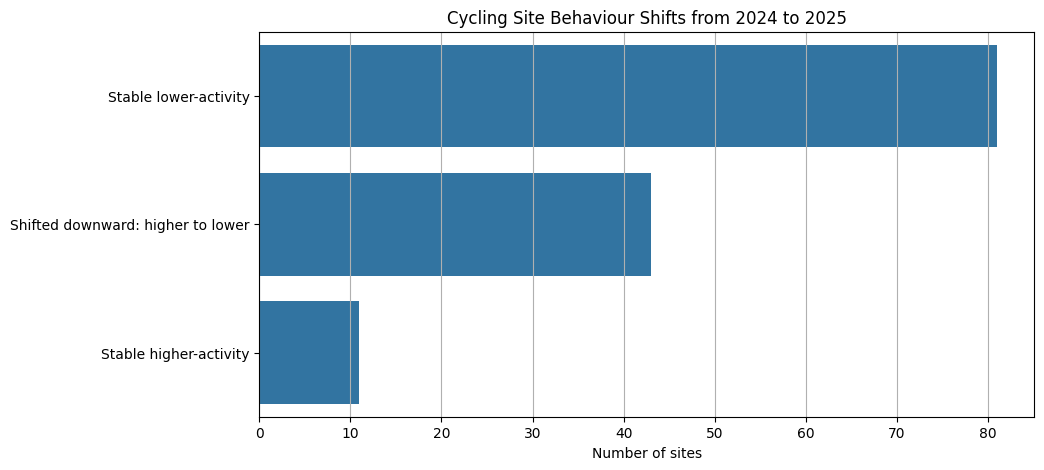

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=comparison_df,
    y="shift_type",
    order=comparison_df["shift_type"].value_counts().index
)

plt.title("Cycling Site Behaviour Shifts from 2024 to 2025")
plt.xlabel("Number of sites")
plt.ylabel("")
plt.grid(axis="x")
plt.show()

In [68]:
comparison_df["shift_type"].value_counts()

,count
shift_type,
Stable lower-activity,81
Shifted downward: higher to lower,43
Stable higher-activity,11


In [69]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
X_2025_sep = active_sites_2025[clustering_features_clean].copy()
X_2025_sep = X_2025_sep.replace([np.inf, -np.inf], np.nan)

X_2025_sep_transformed = X_2025_sep.copy()

for col in count_like_features:
    if col in X_2025_sep_transformed.columns:
        X_2025_sep_transformed[col] = np.log1p(X_2025_sep_transformed[col])

imputer_2025 = SimpleImputer(strategy="median")
X_2025_sep_imputed = imputer_2025.fit_transform(X_2025_sep_transformed)

scaler_2025 = StandardScaler()
X_2025_sep_scaled = scaler_2025.fit_transform(X_2025_sep_imputed)

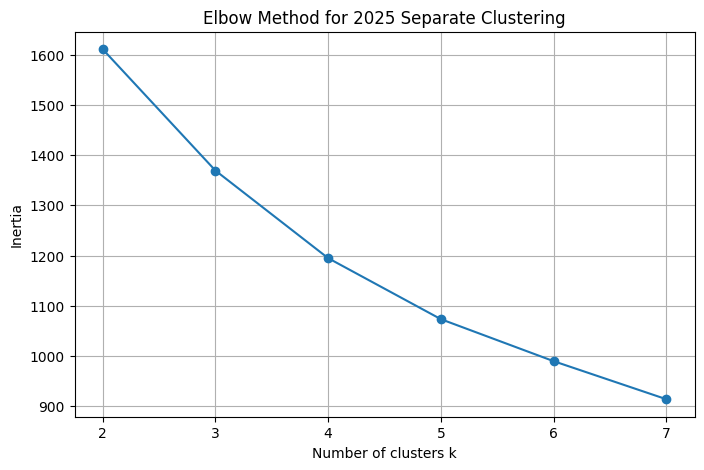

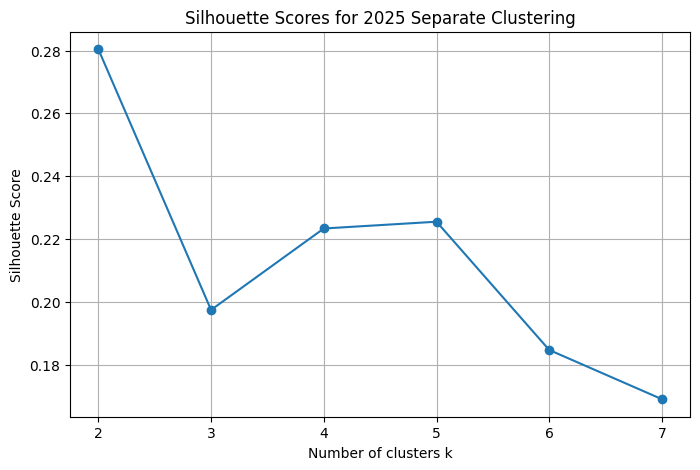

In [71]:
inertias_2025 = []
silhouette_scores_2025 = []

K_range = range(2, 8)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_2025_sep_scaled)

    inertias_2025.append(km.inertia_)
    silhouette_scores_2025.append(silhouette_score(X_2025_sep_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias_2025, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for 2025 Separate Clustering")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_2025, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for 2025 Separate Clustering")
plt.grid(True)
plt.show()

In [72]:
kmeans_2025_separate = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

active_sites_2025["cluster_2025_separate_raw"] = kmeans_2025_separate.fit_predict(
    X_2025_sep_scaled
)

active_sites_2025["cluster_2025_separate_raw"].value_counts().sort_index()

,count
cluster_2025_separate_raw,
0,105
1,42


In [75]:
cluster_mean_counts_2025 = active_sites_2025.groupby(
    "cluster_2025_separate_raw"
)["mean_count"].mean()

higher_cluster_2025 = cluster_mean_counts_2025.idxmax()

active_sites_2025 = active_sites_2025.copy()

active_sites_2025["cluster_2025_separate"] = active_sites_2025[
    "cluster_2025_separate_raw"
].apply(lambda x: 1 if x == higher_cluster_2025 else 0)

separate_cluster_labels = {
    0: "Lower-activity / peripheral sites",
    1: "Higher-activity / infrastructure-supported sites"
}

active_sites_2025["cluster_label_2025_separate"] = active_sites_2025[
    "cluster_2025_separate"
].map(separate_cluster_labels)

active_sites_2025["cluster_label_2025_separate"].value_counts()

,count
cluster_label_2025_separate,
Lower-activity / peripheral sites,105
Higher-activity / infrastructure-supported sites,42


In [76]:
pd.crosstab(
    active_sites_2025["cluster_label_2025"],
    active_sites_2025["cluster_label_2025_separate"],
    margins=True
)

cluster_label_2025_separate,Higher-activity / infrastructure-supported sites,Lower-activity / peripheral sites,All
cluster_label_2025,,,
Higher-activity / infrastructure-supported sites,12,0,12
Lower-activity / peripheral sites,30,105,135
All,42,105,147


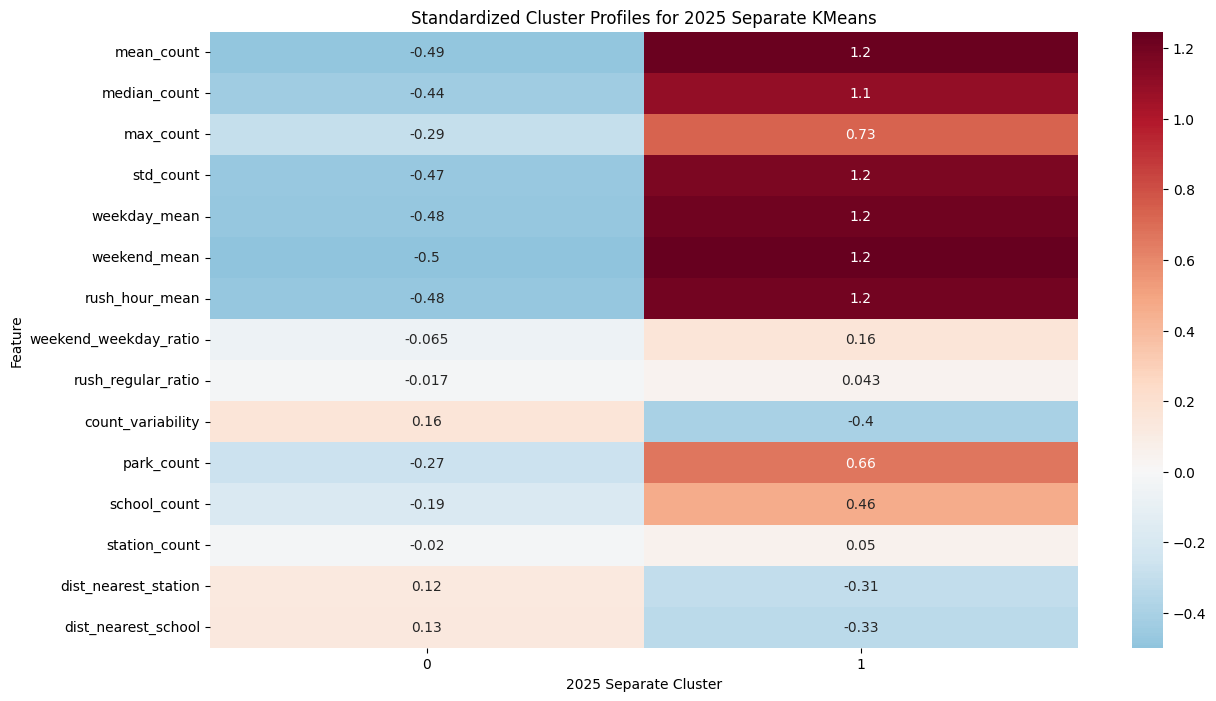

In [77]:
scaled_2025_sep_df = pd.DataFrame(
    X_2025_sep_scaled,
    columns=clustering_features_clean
)

scaled_2025_sep_df["cluster"] = active_sites_2025["cluster_2025_separate"].values

scaled_2025_sep_summary = scaled_2025_sep_df.groupby("cluster").mean()

plt.figure(figsize=(14, 8))
sns.heatmap(
    scaled_2025_sep_summary.T,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Standardized Cluster Profiles for 2025 Separate KMeans")
plt.xlabel("2025 Separate Cluster")
plt.ylabel("Feature")
plt.show()

In [78]:
ari = adjusted_rand_score(
    active_sites_2025["cluster_2025"],
    active_sites_2025["cluster_2025_separate"]
)

nmi = normalized_mutual_info_score(
    active_sites_2025["cluster_2025"],
    active_sites_2025["cluster_2025_separate"]
)

print("Adjusted Rand Index:", round(ari, 3))
print("Normalized Mutual Information:", round(nmi, 3))

Adjusted Rand Index: 0.253
Normalized Mutual Information: 0.254


In [79]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

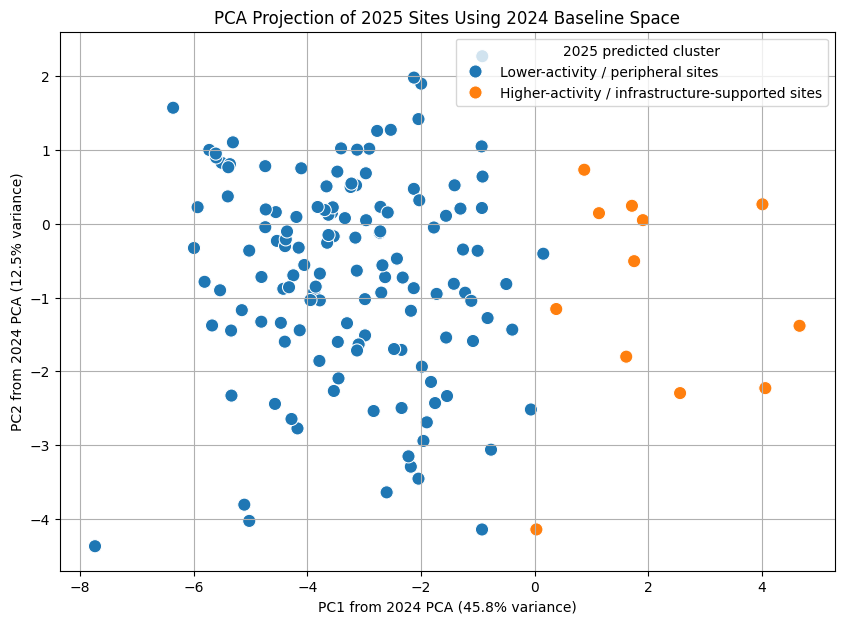

In [80]:
# Fit PCA on 2024 scaled features
pca_2024_space = PCA(n_components=2, random_state=42)
pca_2024_space.fit(X_active_scaled)

# Project 2025 into the 2024 PCA space
pca_2025_result = pca_2024_space.transform(X_2025_scaled)

active_sites_2025["PC1_2025"] = pca_2025_result[:, 0]
active_sites_2025["PC2_2025"] = pca_2025_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=active_sites_2025,
    x="PC1_2025",
    y="PC2_2025",
    hue="cluster_label_2025",
    s=90
)

plt.title("PCA Projection of 2025 Sites Using 2024 Baseline Space")
plt.xlabel(f"PC1 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="2025 predicted cluster")
plt.grid(True)
plt.show()

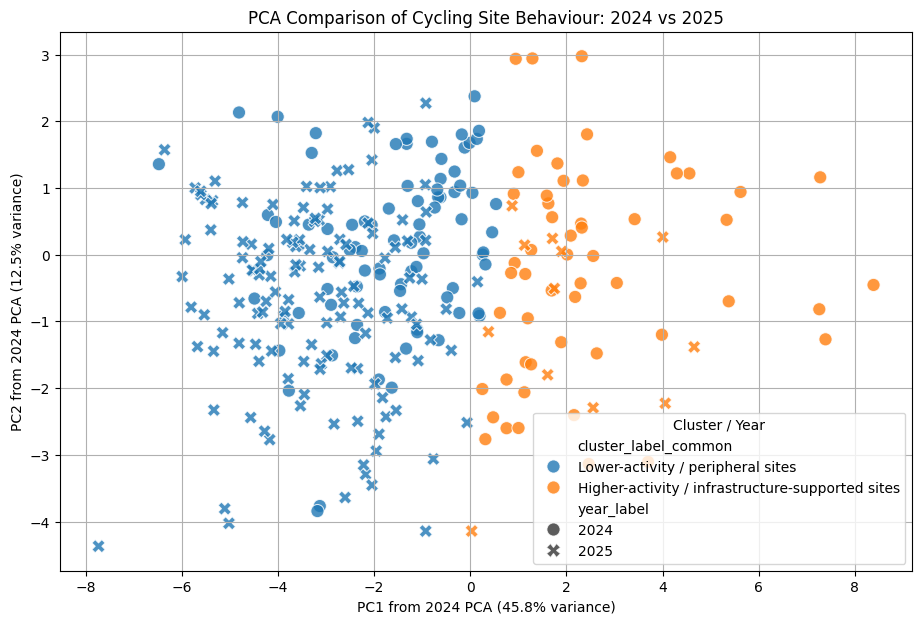

In [81]:
# 2024 PCA coordinates
pca_2024_result = pca_2024_space.transform(X_active_scaled)

active_sites_2024["PC1"] = pca_2024_result[:, 0]
active_sites_2024["PC2"] = pca_2024_result[:, 1]
active_sites_2024["year_label"] = "2024"
active_sites_2024["cluster_label_common"] = active_sites_2024["cluster_label_2024"]

# 2025 PCA coordinates
active_sites_2025["PC1"] = pca_2025_result[:, 0]
active_sites_2025["PC2"] = pca_2025_result[:, 1]
active_sites_2025["year_label"] = "2025"
active_sites_2025["cluster_label_common"] = active_sites_2025["cluster_label_2025"]

pca_compare_df = pd.concat(
    [
        active_sites_2024[["site_id", "PC1", "PC2", "year_label", "cluster_label_common"]],
        active_sites_2025[["site_id", "PC1", "PC2", "year_label", "cluster_label_common"]]
    ],
    ignore_index=True
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_compare_df,
    x="PC1",
    y="PC2",
    hue="cluster_label_common",
    style="year_label",
    s=90,
    alpha=0.8
)

plt.title("PCA Comparison of Cycling Site Behaviour: 2024 vs 2025")
plt.xlabel(f"PC1 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 from 2024 PCA ({pca_2024_space.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster / Year")
plt.grid(True)
plt.show()

In [82]:
comparison_df = active_sites_2024[
    [
        "site_id",
        "cluster_2024",
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ]
].merge(
    active_sites_2025[
        [
            "site_id",
            "cluster_2025",
            "cluster_label_2025",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "lat",
            "lon",
            "municipality",
            "site_name"
        ]
    ],
    on="site_id",
    how="inner",
    suffixes=("_2024", "_2025")
)

def classify_shift(row):
    if row["cluster_2024"] == 0 and row["cluster_2025"] == 0:
        return "Stable lower-activity"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 1:
        return "Stable higher-activity"
    elif row["cluster_2024"] == 0 and row["cluster_2025"] == 1:
        return "Shifted upward: lower to higher"
    elif row["cluster_2024"] == 1 and row["cluster_2025"] == 0:
        return "Shifted downward: higher to lower"
    else:
        return "Other"

comparison_df["shift_type"] = comparison_df.apply(classify_shift, axis=1)

comparison_df["delta_mean_count"] = (
    comparison_df["mean_count_2025"] - comparison_df["mean_count_2024"]
)

comparison_df["percent_change_mean_count"] = (
    comparison_df["delta_mean_count"] /
    (comparison_df["mean_count_2024"] + 1e-6)
) * 100

comparison_df["shift_type"].value_counts()

,count
shift_type,
Stable lower-activity,81
Shifted downward: higher to lower,43
Stable higher-activity,11


In [83]:
import plotly.express as px

fig = px.scatter_mapbox(
    comparison_df,
    lat="lat",
    lon="lon",
    color="shift_type",
    size="mean_count_2025",
    hover_name="site_id",
    hover_data=[
        "site_name",
        "municipality",
        "cluster_label_2024",
        "cluster_label_2025",
        "mean_count_2024",
        "mean_count_2025",
        "delta_mean_count",
        "percent_change_mean_count"
    ],
    zoom=7,
    mapbox_style="carto-positron",
    title="Spatial Shift in Cycling Site Behaviour: 2024 to 2025"
)

fig.update_layout(
    legend_title_text="Shift type",
    margin={"r": 0, "t": 45, "l": 0, "b": 0}
)

fig.show()

In [84]:
fig_2024 = px.scatter_mapbox(
    active_sites_2024,
    lat="lat",
    lon="lon",
    color="cluster_label_2024",
    size="mean_count",
    hover_name="site_id",
    hover_data=[
        "cluster_label_2024",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ],
    zoom=7,
    mapbox_style="carto-positron",
    title="2024 Cycling Site Clusters"
)

fig_2024.update_layout(
    legend_title_text="2024 cluster",
    margin={"r": 0, "t": 45, "l": 0, "b": 0}
)

fig_2024.show()

In [85]:
fig_2025 = px.scatter_mapbox(
    active_sites_2025,
    lat="lat",
    lon="lon",
    color="cluster_label_2025",
    size="mean_count",
    hover_name="site_id",
    hover_data=[
        "cluster_label_2025",
        "mean_count",
        "weekday_mean",
        "weekend_mean",
        "rush_hour_mean"
    ],
    zoom=7,
    mapbox_style="carto-positron",
    title="2025 Cycling Site Clusters Predicted from 2024 Model"
)

fig_2025.update_layout(
    legend_title_text="2025 predicted cluster",
    margin={"r": 0, "t": 45, "l": 0, "b": 0}
)

fig_2025.show()

In [86]:
df_2025["month"].value_counts().sort_index()

,count
month,
1,829178
2,751176
3,822560
4,793732
5,827328
6,806400
7,837562
8,855838
9,823836


In [87]:
df_2024["month"].value_counts().sort_index()

,count
month,
1,205344
2,192096
3,205344
4,198720
5,204154
6,197280
7,203856
8,205172
9,197280


In [88]:
infra_cols = ["school_count", "park_count", "station_count"]

for col in infra_cols:
    if col in active_sites_2024.columns:
        zero_pct_2024 = (active_sites_2024[col] == 0).mean() * 100
        print(f"2024 {col}: {zero_pct_2024:.1f}% zeros")

print("\n--- 2025 ---")

for col in infra_cols:
    if col in active_sites_2025.columns:
        zero_pct_2025 = (active_sites_2025[col] == 0).mean() * 100
        print(f"2025 {col}: {zero_pct_2025:.1f}% zeros")

2024 school_count: 51.5% zeros
2024 park_count: 48.5% zeros
2024 station_count: 91.9% zeros

--- 2025 ---
2025 school_count: 51.0% zeros
2025 park_count: 47.6% zeros
2025 station_count: 91.2% zeros


In [89]:
active_sites_2024.groupby("cluster_label_2024")[
    ["school_count", "park_count", "station_count"]
].mean().round(2)

,school_count,park_count,station_count
cluster_label_2024,,,
Higher-activity / infrastructure-supported sites,3.11,2.89,0.2
Lower-activity / peripheral sites,0.62,0.62,0.0
